Loading datasets and mapping dictionaries...
Pruning network to isolate primary biological hubs...
Building network graph and applying geometric isolation...
Rendering high-resolution visualization...


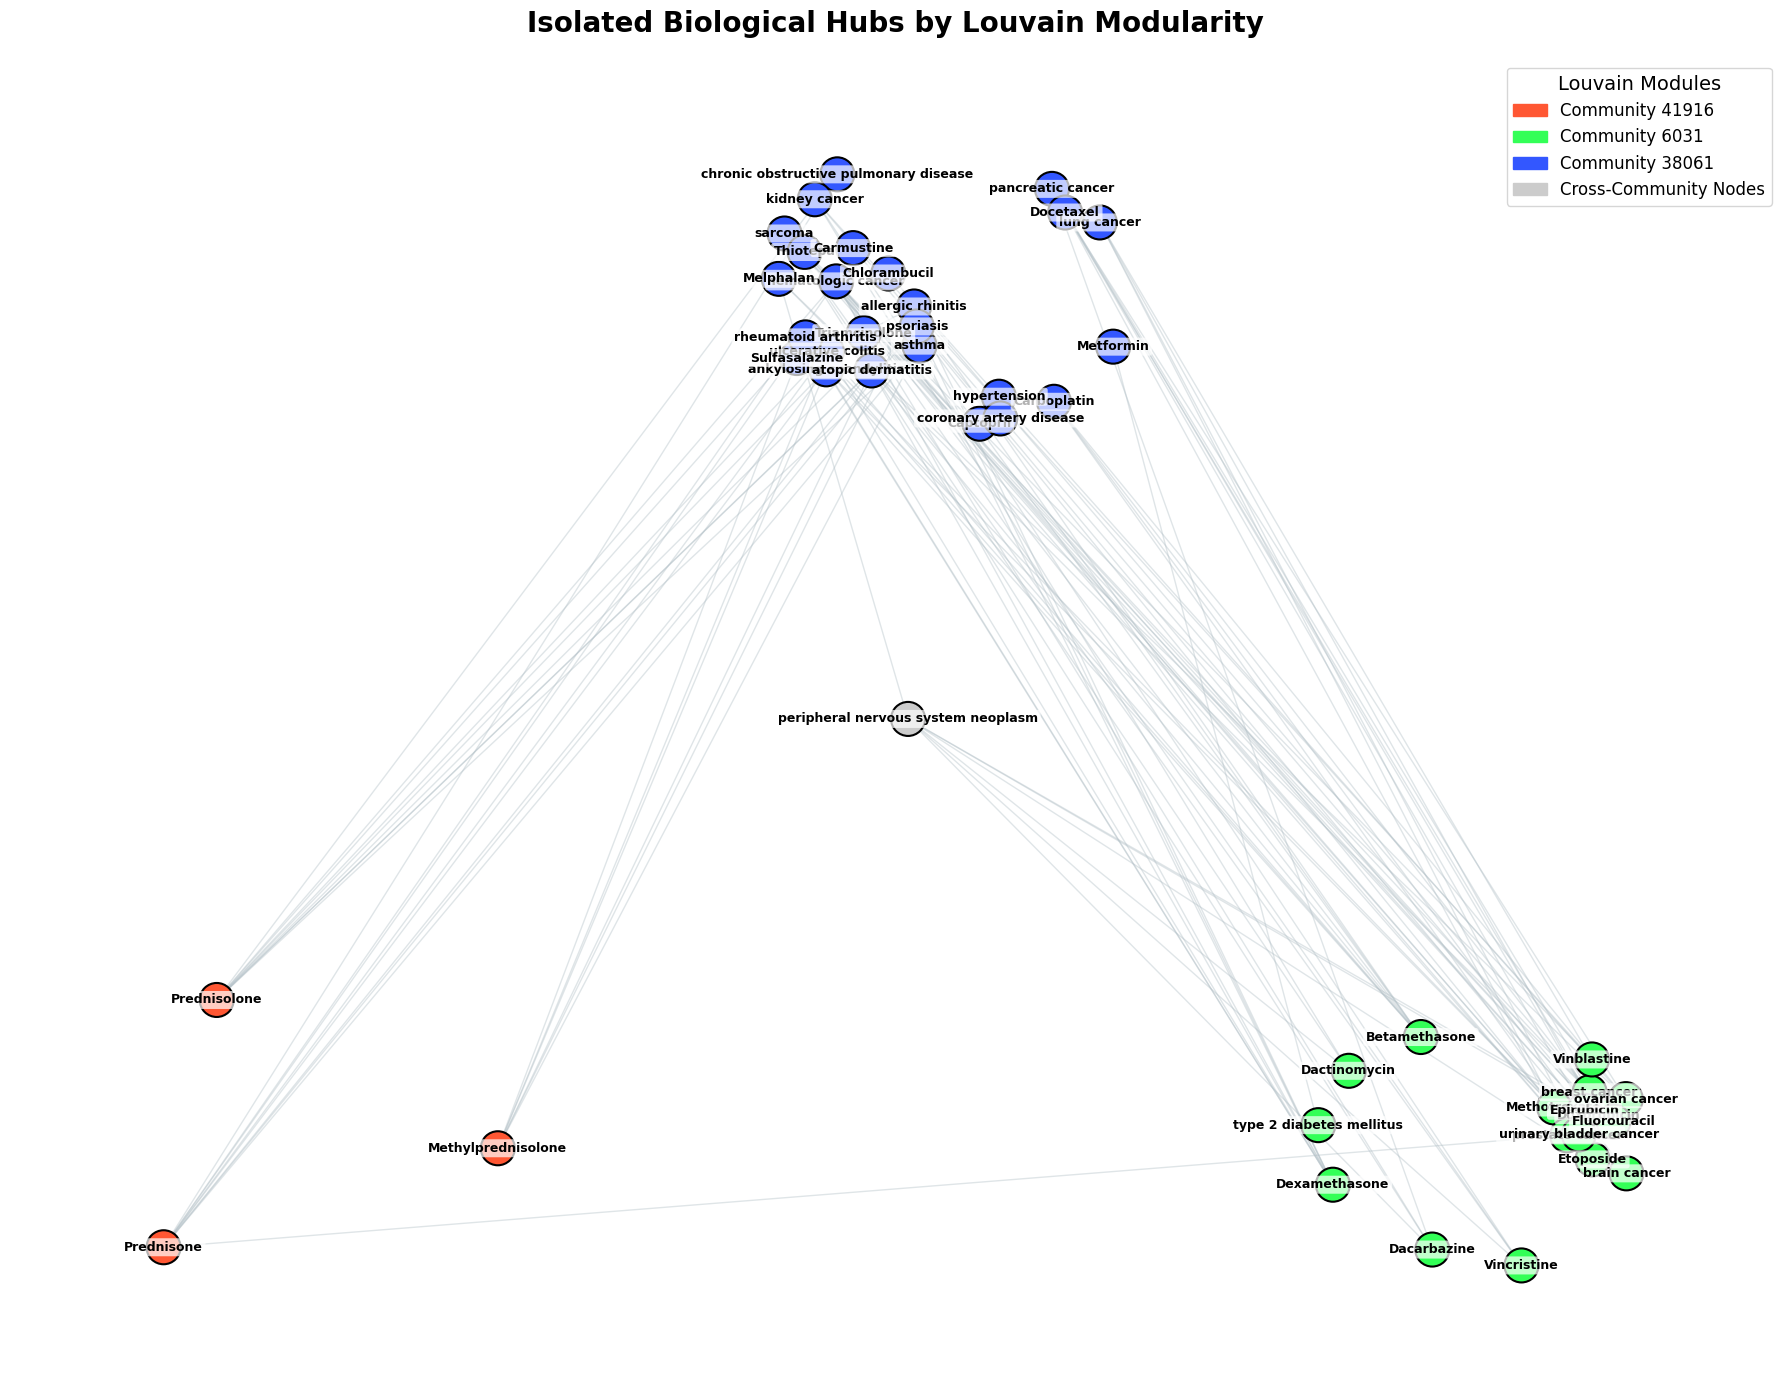

Saved clean visualization as 'louvain_communities_cleaned.png'


In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("Loading datasets and mapping dictionaries...")
ml_dataset = pd.read_csv('baseline_ml_dataset.csv')
graph_metrics = pd.read_csv('graph_metrics.csv')
nodes_df = pd.read_csv('neo4j_nodes.csv')

id_to_name = dict(zip(nodes_df['id'], nodes_df['name']))
id_to_comm = dict(zip(graph_metrics['id'], graph_metrics['louvain']))

# Filtering to only known, valid therapeutic links
valid_edges = ml_dataset[ml_dataset['label'] == 1].copy()
valid_edges = valid_edges.merge(graph_metrics[['id', 'louvain']], left_on='source', right_on='id', how='left')

# Identifying the top 3 largest communities
top_communities = valid_edges['louvain'].value_counts().head(3).index.tolist()

print("Pruning network to isolate primary biological hubs...")
# Keeping only the top 20 most connected nodes per community to eliminate clutter
nodes_to_keep = set()
for comm in top_communities:
    comm_edges = valid_edges[valid_edges['louvain'] == comm]
    comm_nodes = pd.concat([comm_edges['source'], comm_edges['target']])
    top_hubs = comm_nodes.value_counts().head(20).index.tolist()
    nodes_to_keep.update(top_hubs)

# Filtering edges where both source and target are in our pruned hub list
subgraph_edges = valid_edges[
    (valid_edges['source'].isin(nodes_to_keep)) & 
    (valid_edges['target'].isin(nodes_to_keep))
]

print("Building network graph and applying geometric isolation...")
G = nx.Graph()

for _, row in subgraph_edges.iterrows():
    source_id, target_id = row['source'], row['target']
    source_name = id_to_name.get(source_id, source_id)
    target_name = id_to_name.get(target_id, target_id)
    
    # Mapping nodes strictly to their real communities
    G.add_node(source_name, community=id_to_comm.get(source_id, row['louvain']))
    G.add_node(target_name, community=id_to_comm.get(target_id, row['louvain']))
    G.add_edge(source_name, target_name)

# Forcing communities into distinct, separated areas on the canvas
pos = {}
centers = [(-3, -3), (3, -3), (0, 3)] 

# Identifying all unique communities that actually made it into the graph subset
unique_comms_in_graph = set(nx.get_node_attributes(G, 'community').values())

for comm in unique_comms_in_graph:
    # Extracting nodes belonging to this specific community
    comm_nodes = [n for n, d in G.nodes(data=True) if d.get('community') == comm]
    sub_G = G.subgraph(comm_nodes)
    
    # If it's one of the top 3, assigning its specific corner. Otherwise, putting it in the middle.
    if comm in top_communities:
        center = centers[top_communities.index(comm)]
    else:
        center = (0, 0)
        
    # Calculating a localized layout anchored to its designated center point
    sub_pos = nx.spring_layout(sub_G, center=center, k=0.8, iterations=100, seed=42)
    pos.update(sub_pos)

print("Rendering high-resolution visualization...")
color_palette = {
    top_communities[0]: '#FF5733', # Vibrant Red-Orange
    top_communities[1]: '#33FF57', # Vibrant Green
    top_communities[2]: '#3357FF'  # Vibrant Blue
}

# Assign colors; fallback to gray if a cross-community target slipped in
node_colors = [color_palette.get(nx.get_node_attributes(G, 'community')[node], '#CCCCCC') for node in G.nodes()]

plt.figure(figsize=(18, 14))
plt.title("Isolated Biological Hubs by Louvain Modularity", fontsize=20, fontweight='bold', pad=20)

# Drawing lines with lower opacity so they act as background context
nx.draw_networkx_edges(G, pos, edge_color='#B0BEC5', alpha=0.4, width=1.0)

# Drawing the nodes larger to emphasize the hubs
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, edgecolors='black', linewidths=1.5)

# Adding text labels with a semi-transparent background box to prevent overlapping lines from obscuring text
nx.draw_networkx_labels(
    G, pos, 
    font_size=9, 
    font_weight='bold', 
    font_family='sans-serif',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2')
)

# Generating a clean legend
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color, label=f'Community {comm_id}') for comm_id, color in color_palette.items()]
# Adding the grey label for the cross-community bridge nodes
legend_handles.append(mpatches.Patch(color='#CCCCCC', label='Cross-Community Nodes'))

plt.legend(handles=legend_handles, title="Louvain Modules", loc='upper right', fontsize=12, title_fontsize=14)

plt.axis('off')
plt.tight_layout()
plt.savefig('louvain_communities_cleaned.png', dpi=300, facecolor='#F8F9FA')
plt.show()

print("Saved clean visualization as 'louvain_communities_cleaned.png'")

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def generate_community_triplet_plot(valid_edges, comm_list, id_to_name, id_to_comm, filename_suffix):
    nodes_to_keep = set()
    for comm in comm_list:
        comm_edges = valid_edges[valid_edges['louvain'] == comm]
        comm_nodes = pd.concat([comm_edges['source'], comm_edges['target']])
        top_hubs = comm_nodes.value_counts().head(20).index.tolist()
        nodes_to_keep.update(top_hubs)

    subgraph_edges = valid_edges[
        (valid_edges['source'].isin(nodes_to_keep)) & 
        (valid_edges['target'].isin(nodes_to_keep))
    ]

    G = nx.Graph()
    for _, row in subgraph_edges.iterrows():
        source_id, target_id = row['source'], row['target']
        G.add_node(id_to_name.get(source_id, source_id), community=id_to_comm.get(source_id, row['louvain']))
        G.add_node(id_to_name.get(target_id, target_id), community=id_to_comm.get(target_id, row['louvain']))
        G.add_edge(id_to_name.get(source_id, source_id), id_to_name.get(target_id, target_id))

    pos = {}
    centers = [(-3, -3), (3, -3), (0, 3)] 
    unique_comms = set(nx.get_node_attributes(G, 'community').values())

    for comm in unique_comms:
        sub_G = G.subgraph([n for n, d in G.nodes(data=True) if d.get('community') == comm])
        center = centers[comm_list.index(comm)] if comm in comm_list else (0, 0)
        pos.update(nx.spring_layout(sub_G, center=center, k=0.8, iterations=100, seed=42))

    color_map = ['#FF5733', '#33FF57', '#3357FF']
    color_palette = {comm: color_map[i] for i, comm in enumerate(comm_list)}
    node_colors = [color_palette.get(nx.get_node_attributes(G, 'community')[node], '#CCCCCC') for node in G.nodes()]

    plt.figure(figsize=(16, 12))
    plt.title(f"Biological Hubs: Communities {comm_list}", fontsize=18, fontweight='bold', pad=20)
    
    nx.draw_networkx_edges(G, pos, edge_color='#B0BEC5', alpha=0.4, width=1.0)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors='black', linewidths=1.0)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    handles = [mpatches.Patch(color=color, label=f'Community {comm}') for comm, color in color_palette.items()]
    handles.append(mpatches.Patch(color='#CCCCCC', label='Cross-Community Bridges'))
    plt.legend(handles=handles, loc='upper right')

    plt.axis('off')
    plt.tight_layout()
    filename = f'louvain_hubs_{filename_suffix}.png'
    plt.savefig(filename, dpi=300, facecolor='#F8F9FA')
    plt.close()
    print(f"Saved {filename}")

print("Extracting top 6 communities...")
top_9_communities = valid_edges['louvain'].value_counts().head(9).index.tolist()

# Chunking the top 6 communities into groups of 3
for i in range(0, 6, 3):
    triplet = top_9_communities[i:i+3]
    print(f"Generating plot for communities: {triplet}")
    generate_community_triplet_plot(valid_edges, triplet, id_to_name, id_to_comm, f"rank_{i+1}_to_{i+3}")

Extracting top 6 communities...
Generating plot for communities: [41916, 6031, 38061]
Saved louvain_hubs_rank_1_to_3.png
Generating plot for communities: [39757, 42209, 35517]
Saved louvain_hubs_rank_4_to_6.png


In [13]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

print("Calculating geometrically isolated 3D physics...")

# Using the top 4 communities for the 3D model
top_4_comms = valid_edges['louvain'].value_counts().head(4).index.tolist()

nodes_to_keep_3d = set()
for comm in top_4_comms:
    comm_edges = valid_edges[valid_edges['louvain'] == comm]
    comm_nodes = pd.concat([comm_edges['source'], comm_edges['target']])
    nodes_to_keep_3d.update(comm_nodes.value_counts().head(25).index.tolist())

subgraph_edges_3d = valid_edges[
    (valid_edges['source'].isin(nodes_to_keep_3d)) & 
    (valid_edges['target'].isin(nodes_to_keep_3d))
]

G_3d = nx.Graph()
for _, row in subgraph_edges_3d.iterrows():
    source_id, target_id = row['source'], row['target']
    G_3d.add_node(id_to_name.get(source_id, source_id), community=id_to_comm.get(source_id, row['louvain']))
    G_3d.add_node(id_to_name.get(target_id, target_id), community=id_to_comm.get(target_id, row['louvain']))
    G_3d.add_edge(id_to_name.get(source_id, source_id), id_to_name.get(target_id, target_id))

# Forcing communities into distinct 3D Tetrahedron coordinates
# Points: (x, y, z) structured to be equidistant from each other
centers_3d = [
    (10, 10, 10),     # Top Right Front
    (10, -10, -10),   # Bottom Right Back
    (-10, 10, -10),   # Top Left Back
    (-10, -10, 10)    # Bottom Left Front
]

pos_3d = {}
unique_comms_3d = set(nx.get_node_attributes(G_3d, 'community').values())

for comm in unique_comms_3d:
    comm_nodes = [n for n, d in G_3d.nodes(data=True) if d.get('community') == comm]
    sub_G = G_3d.subgraph(comm_nodes)
    
    if comm in top_4_comms:
        center = centers_3d[top_4_comms.index(comm)]
    else:
        center = (0, 0, 0)
        
    sub_pos = nx.spring_layout(sub_G, dim=3, center=center, k=0.8, iterations=100, seed=42)
    pos_3d.update(sub_pos)

x_nodes, y_nodes, z_nodes = [], [], []
node_colors, hover_texts = [], []

color_map_3d = {
    top_4_comms[0]: '#FF3366', # Neon Pink
    top_4_comms[1]: '#00E5FF', # Cyan
    top_4_comms[2]: '#FFD500', # Yellow
    top_4_comms[3]: '#00E676'  # Neon Green
}

for node in G_3d.nodes():
    x, y, z = pos_3d[node]
    x_nodes.append(x)
    y_nodes.append(y)
    z_nodes.append(z)
    
    comm = nx.get_node_attributes(G_3d, 'community')[node]
    node_colors.append(color_map_3d.get(comm, '#888888')) # Gray for cross-community bridges
    hover_texts.append(f"<b>{node}</b><br>Community: {comm}")

# Extract edge coordinates for Plotly
x_edges, y_edges, z_edges = [], [], []
for edge in G_3d.edges():
    x0, y0, z0 = pos_3d[edge[0]]
    x1, y1, z1 = pos_3d[edge[1]]
    x_edges.extend([x0, x1, None])
    y_edges.extend([y0, y1, None])
    z_edges.extend([z0, z1, None])

print("Rendering isolated Plotly figure...")

# Create the Edge traces
trace_edges = go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='rgba(150,150,150,0.3)', width=1.5),
    hoverinfo='none'
)

trace_nodes = go.Scatter3d(
    x=x_nodes, y=y_nodes, z=z_nodes,
    mode='markers',
    marker=dict(
        size=7,
        color=node_colors,
        line=dict(color='black', width=0.5),
        opacity=0.9
    ),
    text=hover_texts,
    hoverinfo='text'
)

layout = go.Layout(
    title=dict(text='Interactive 3D Biological Hubs (Geometrically Isolated)', font=dict(color='white', size=20)),
    paper_bgcolor='#121212', 
    scene=dict(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, backgroundcolor='#121212'),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, backgroundcolor='#121212'),
        zaxis=dict(showgrid=False, zeroline=False, showticklabels=False, backgroundcolor='#121212')
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    showlegend=False
)

fig = go.Figure(data=[trace_edges, trace_nodes], layout=layout)

fig.write_html("interactive_3d_network_isolated.html")
print("Saved distinct 3D graph as 'interactive_3d_network_isolated.html'.")

Calculating geometrically isolated 3D physics...
Rendering isolated Plotly figure...
Saved distinct 3D graph as 'interactive_3d_network_isolated.html'.
